In [2]:
import numpy as np
import matplotlib.pyplot as plt
import torch
from torch import nn
import pandas as pd
import json

### Reweighting

An example of the training data, consisting of $N$ hadronization events (in the dataset below $N = 10,000$), is:
$$
\boldsymbol{z} = 
  \begin{pmatrix}
    \boldsymbol{z}_1 = 
    \begin{pmatrix} 
        \big\{ \texttt{idOld}^{1}, \texttt{idNew}^1, m_T^{h_1}, z^{h_1}_{\text{accept}}, z^{1, h_1}_{\text{reject}}, z^{2, h_1}_{\text{reject}}, \cdots, 									  z^{n_{h_1}, h_1}_{\text{reject}}\big\} \\
        \big\{  \texttt{idOld}^{2}, \texttt{idNew}^2, m_T^{h_2}, z^{h_2}_{\text{accept}}, z^{1, h_2}_{\text{reject}}, z^{2, h_2}_{\text{reject}}, \cdots, z^{n_{h_2}, h_2}_{\text{reject}} \big\} \\	
        \big\{ \texttt{idOld}^{3}, \texttt{idNew}^3, m_T^{h_3}, z^{h_3}_{\text{accept}}, z^{1, h_3}_{\text{reject}}, z^{2, h_3}_{\text{reject}}, \cdots, z^{n_{h_3}, h_3}_{\text{reject}} \big\} 
        \end{pmatrix}_1 \\
    \boldsymbol{z}_2 = 
    \begin{pmatrix} 
      \big\{ \texttt{idOld}^{1}, \texttt{idNew}^1, m_T^{h_1}, z^{h_1}_{\text{accept}}, z^{1, h_1}_{\text{reject}}, z^{2, h_1}_{\text{reject}}, \cdots, z^{n_{h_1}, h_1}_{\text{reject}}\big\} \\
      \vdots \\	
      \big\{ \texttt{idOld}^{4}, \texttt{idNew}^4, m_T^{h_4}, z^{h_4}_{\text{accept}}, z^{1, h_4}_{\text{reject}}, z^{2, h_4}_{\text{reject}}, \cdots, z^{n_{h_4}, h_4}_{\text{reject}} \big\} 
      \end{pmatrix}_2 \\
      \vdots \\
    \boldsymbol{z}_N = \cdots
  \end{pmatrix},
$$
$$
\boldsymbol{y}_\text{sim} = 
  \begin{pmatrix}
    \boldsymbol{y}_1 = N_{h,1} = 3\\
    \boldsymbol{y}_2 = N_{h,2} = 4 \\
    \vdots \\
    \boldsymbol{y}_N = N_{h,N} = 2
\end{pmatrix}
$$
Note that each array $\boldsymbol{z}_i$ is zero-padded to a fixed length of size $105$ and each accept-reject array is zero-padded to a fixed length of size $101$ (the maximum number of rejections is 100).

In [3]:
# Load accept-reject and hadron data (for base parameterization) 
# accept_reject_base_PATH = './model_test/pgun_uubar_id_mT2_accept_reject_model_test_base_N_1e4.npy'
# accept_reject_base_PATH = '/pscratch/sd/l/ljpuslar/RSA/RSA/data/structured_data/pgun_uubar__a0.72_b0.88_aD0_aU0_aS0_aC0_aB0_aH0.97_bD0.88_bU0.88_bS0.88_bC0.88_bB0.88_bH0.88_sigma_0.335_N_1.0e+05_id_mT2_accept_reject_z.npy'
# accept_reject_base_PATH = '/pscratch/sd/l/ljpuslar/RSA/RSA/data/structured_data/pgun_uubar__a0.76_b0.84_aD0_aU0_aS0_aC0_aB0_aH0.97_bD0.84_bU0.84_bS0.84_bC0.84_bB0.84_bH0.84_sigma_0.335_N_1.0e+05_id_mT2_accept_reject_z.npy'
# accept_reject_base_PATH = '/pscratch/sd/l/ljpuslar/RSA/RSA/data/structured_data/pgun_uubar__a0.68_b0.98_aD0_aU0_aS0_aC0_aB0_aH0.97_bD0.98_bU0.98_bS0.98_bC0.98_bB0.98_bH0.98_sigma_0.335_N_1.0e+05_id_mT2_accept_reject_z.npy'
accept_reject_base_PATH = '/pscratch/sd/l/ljpuslar/RSA/RSA/data/structured_data/pgun_uubar_allhad_a0.68_b0.98_aD0_aU0_aS0_aC0_aB0_aH0.97_bD0.98_bU0.98_bS0.98_bC0.98_bB0.98_bH0.98_sigma_0.335_N_1.0e+05_id_mT2_accept_reject_z.npy'
pgun_accept_reject_base = np.load(accept_reject_base_PATH, mmap_mode = "r")

# fPrel_base_PATH = '/pscratch/sd/l/ljpuslar/RSA/RSA/data/structured_data/pgun_uubar__a0.72_b0.88_aD0_aU0_aS0_aC0_aB0_aH0.97_bD0.88_bU0.88_bS0.88_bC0.88_bB0.88_bH0.88_sigma_0.335_N_1.0e+05_fPrel.npy'
# fPrel_base_PATH = '/pscratch/sd/l/ljpuslar/RSA/RSA/data/structured_data/pgun_uubar__a0.76_b0.84_aD0_aU0_aS0_aC0_aB0_aH0.97_bD0.84_bU0.84_bS0.84_bC0.84_bB0.84_bH0.84_sigma_0.335_N_1.0e+05_fPrel.npy'
# fPrel_base_PATH = '/pscratch/sd/l/ljpuslar/RSA/RSA/data/structured_data/pgun_uubar__a0.68_b0.98_aD0_aU0_aS0_aC0_aB0_aH0.97_bD0.98_bU0.98_bS0.98_bC0.98_bB0.98_bH0.98_sigma_0.335_N_1.0e+05_fPrel.npy'
fPrel_base_PATH = '/pscratch/sd/l/ljpuslar/RSA/RSA/data/structured_data/pgun_uubar_allhad_a0.68_b0.98_aD0_aU0_aS0_aC0_aB0_aH0.97_bD0.98_bU0.98_bS0.98_bC0.98_bB0.98_bH0.98_sigma_0.335_N_1.0e+05_fPrel.npy'
pgun_fPrel_base = np.load(fPrel_base_PATH, mmap_mode = "r")

# filename_hadrons_base = '/pscratch/sd/l/ljpuslar/RSA/RSA/data/structured_data/pgun_uubar__a0.72_b0.88_aD0_aU0_aS0_aC0_aB0_aH0.97_bD0.88_bU0.88_bS0.88_bC0.88_bB0.88_bH0.88_sigma_0.335_N_1.0e+05_hadrons.npy'
# filename_hadrons_base = '/pscratch/sd/l/ljpuslar/RSA/RSA/data/structured_data/pgun_uubar__a0.76_b0.84_aD0_aU0_aS0_aC0_aB0_aH0.97_bD0.84_bU0.84_bS0.84_bC0.84_bB0.84_bH0.84_sigma_0.335_N_1.0e+05_hadrons.npy'
# filename_hadrons_base = '/pscratch/sd/l/ljpuslar/RSA/RSA/data/structured_data/pgun_uubar__a0.68_b0.98_aD0_aU0_aS0_aC0_aB0_aH0.97_bD0.98_bU0.98_bS0.98_bC0.98_bB0.98_bH0.98_sigma_0.335_N_1.0e+05_hadrons.npy'
filename_hadrons_base = '/pscratch/sd/l/ljpuslar/RSA/RSA/data/structured_data/pgun_uubar_allhad_a0.68_b0.98_aD0_aU0_aS0_aC0_aB0_aH0.97_bD0.98_bU0.98_bS0.98_bC0.98_bB0.98_bH0.98_sigma_0.335_N_1.0e+05_hadrons.npy'
pgun_hadrons_base = np.load(filename_hadrons_base, mmap_mode="r")

# Load the hadron data from the target for comparison
# filename_hadrons_target = '/pscratch/sd/l/ljpuslar/RSA/RSA/data/structured_data/pgun_uubar__a0.68_b0.98_aD0_aU0_aS0_aC0_aB0_aH0.97_bD0.98_bU0.98_bS0.98_bC0.98_bB0.98_bH0.98_sigma_0.335_N_1.0e+05_hadrons.npy'
# filename_hadrons_target = '/pscratch/sd/l/ljpuslar/RSA/RSA/data/structured_data/pgun_uubar__a0.72_b0.88_aD0_aU0_aS0_aC0_aB0_aH0.97_bD0.88_bU0.88_bS0.88_bC0.88_bB0.88_bH0.88_sigma_0.335_N_1.0e+05_hadrons.npy'
# filename_hadrons_target = '/pscratch/sd/l/ljpuslar/RSA/RSA/data/structured_data/pgun_uubar__a0.76_b0.84_aD0_aU0_aS0_aC0_aB0_aH0.97_bD0.84_bU0.84_bS0.84_bC0.84_bB0.84_bH0.84_sigma_0.335_N_1.0e+05_hadrons.npy'
# filename_hadrons_target = '/pscratch/sd/l/ljpuslar/RSA/RSA/data/structured_data/pgun_uubar__a0.68_b0.98_aD0.1_aU-0.1_aS0_aC0_aB0_aH0.97_bD1.08_bU0.88_bS0.98_bC0.98_bB0.98_bH0.98_sigma_0.335_N_1.0e+05_hadrons.npy'
# filename_hadrons_target = '/pscratch/sd/l/ljpuslar/RSA/RSA/data/structured_data/pgun_uubar__a0.68_b0.98_aD0.15_aU0_aS0_aC0_aB0_aH0.97_bD0.68_bU0.98_bS0.98_bC0.98_bB0.98_bH0.98_sigma_0.335_N_1.0e+05_hadrons.npy'
filename_hadrons_target = '/pscratch/sd/l/ljpuslar/RSA/RSA/data/structured_data/pgun_uubar_allhad_a0.68_b0.98_aD0.04_aU0.04_aS0_aC0_aB0_aH0.97_bD0.88_bU0.88_bS0.98_bC0.98_bB0.98_bH0.98_sigma_0.335_N_1.0e+05_hadrons.npy'
pgun_hadrons_target = np.load(filename_hadrons_target, mmap_mode="r")

# accept_reject_target_PATH = '/pscratch/sd/l/ljpuslar/RSA/RSA/data/structured_data/pgun_uubar__a0.68_b0.98_aD0_aU0_aS0_aC0_aB0_aH0.97_bD0.98_bU0.98_bS0.98_bC0.98_bB0.98_bH0.98_sigma_0.335_N_1.0e+05_id_mT2_accept_reject_z.npy'
# accept_reject_target_PATH = '/pscratch/sd/l/ljpuslar/RSA/RSA/data/structured_data/pgun_uubar__a0.72_b0.88_aD0_aU0_aS0_aC0_aB0_aH0.97_bD0.88_bU0.88_bS0.88_bC0.88_bB0.88_bH0.88_sigma_0.335_N_1.0e+05_id_mT2_accept_reject_z.npy'
# accept_reject_target_PATH = '/pscratch/sd/l/ljpuslar/RSA/RSA/data/structured_data/pgun_uubar__a0.76_b0.84_aD0_aU0_aS0_aC0_aB0_aH0.97_bD0.84_bU0.84_bS0.84_bC0.84_bB0.84_bH0.84_sigma_0.335_N_1.0e+05_id_mT2_accept_reject_z.npy'
# accept_reject_target_PATH = '/pscratch/sd/l/ljpuslar/RSA/RSA/data/structured_data/pgun_uubar__a0.68_b0.98_aD0.15_aU0_aS0_aC0_aB0_aH0.97_bD0.68_bU0.98_bS0.98_bC0.98_bB0.98_bH0.98_sigma_0.335_N_1.0e+05_id_mT2_accept_reject_z.npy'
accept_reject_target_PATH = '/pscratch/sd/l/ljpuslar/RSA/RSA/data/structured_data/pgun_uubar_allhad_a0.68_b0.98_aD0.04_aU0.04_aS0_aC0_aB0_aH0.97_bD0.88_bU0.88_bS0.98_bC0.98_bB0.98_bH0.98_sigma_0.335_N_1.0e+05_id_mT2_accept_reject_z.npy'
pgun_accept_reject_target = np.load(accept_reject_target_PATH, mmap_mode = "r")

In [4]:
# Check the shapes
print("Accepted and rejected z data shape:", pgun_accept_reject_base.shape)
print("fPrel data shape:", pgun_fPrel_base.shape)
print("Hadron data shape:", pgun_hadrons_base.shape)
print(pgun_accept_reject_base[0,0])
# print(pgun_hadrons_base[0])

nevents = 100000
pgun_accept_reject_base = pgun_accept_reject_base[:nevents]
pgun_fPrel_base = pgun_fPrel_base[:nevents]
pgun_hadrons_base = pgun_hadrons_base[:nevents]
pgun_accept_reject_target = pgun_accept_reject_target[:nevents]

Accepted and rejected z data shape: (100000, 250, 103)
fPrel data shape: (100000, 250, 100)
Hadron data shape: (100000, 75, 6)
[-2.          1.          0.06377188  0.44814789  0.90154823  0.0187364
  0.08701119  0.14779245  0.50050875  0.09934312  0.61947947  0.
  0.          0.          0.          0.          0.          0.
  0.          0.          0.          0.          0.          0.
  0.          0.          0.          0.          0.          0.
  0.          0.          0.          0.          0.          0.
  0.          0.          0.          0.          0.          0.
  0.          0.          0.          0.          0.          0.
  0.          0.          0.          0.          0.          0.
  0.          0.          0.          0.          0.          0.
  0.          0.          0.          0.          0.          0.
  0.          0.          0.          0.          0.          0.
  0.          0.          0.          0.          0.          0.
  0.          0.     

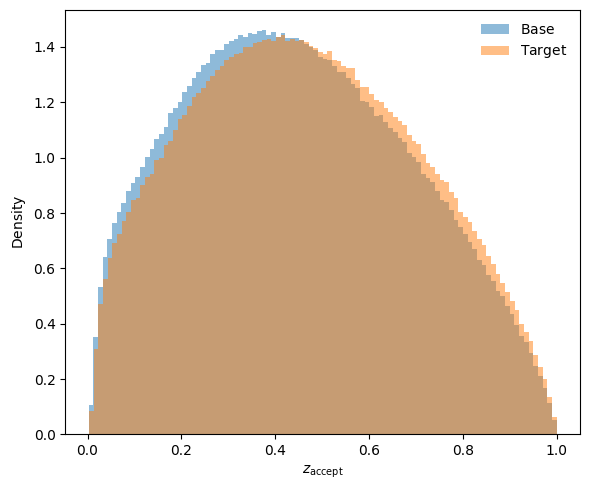

In [5]:
# Histrogram accepted z-values across all events
fig, ax = plt.subplots(1,1,figsize=(6,5))
ax.hist(pgun_accept_reject_target[:,:,3][pgun_accept_reject_target[:,:,3] > 0.0], 100, alpha = 0.5, density = True, label = r"$\mathrm{Base}$")
ax.hist(pgun_accept_reject_base[:,:,3][pgun_accept_reject_base[:,:,3] > 0.0], 100, alpha = 0.5, density = True, label = r"$\mathrm{Target}$")
ax.set_xlabel(r'$z_{\mathrm{accept}}$')
ax.set_ylabel(r'$\mathrm{Density}$')
ax.legend(frameon = False)
fig.tight_layout()

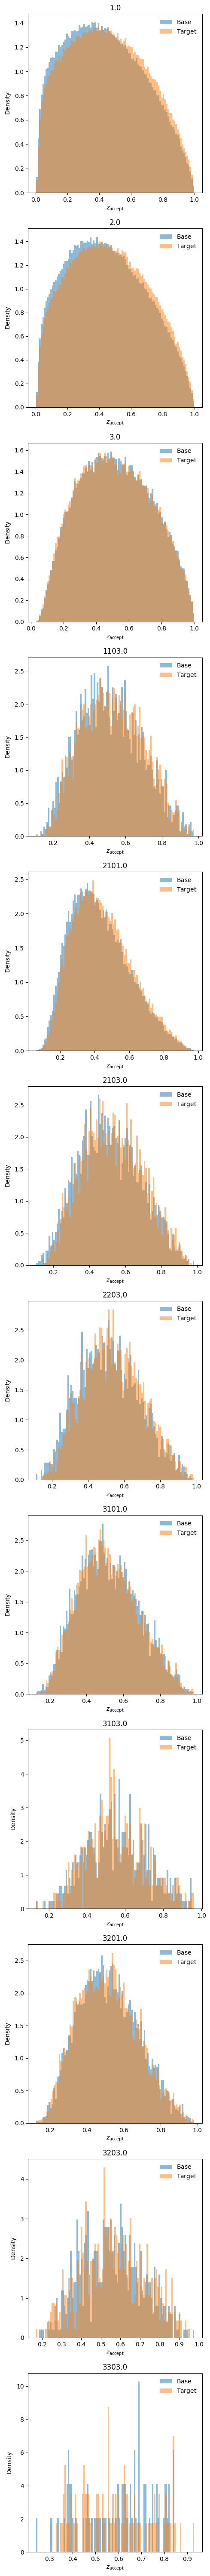

In [6]:
# with open("/pscratch/sd/l/ljpuslar/RSA/RSA/data/files/pythia_particles.json", "r") as f:
#     loaded_particles = json.load(f)

# ids_old = pgun_accept_reject_base[:,:,0][pgun_accept_reject_base[:,:,0] > 0.0]
ids_new = np.abs(pgun_accept_reject_base[:,:,1][pgun_accept_reject_base[:,:,3] > 0.0])

# print(ids_old.shape)
particles, counts = np.unique(ids_new, return_counts=True)
len_par = len(particles)
fig, ax = plt.subplots(len_par,1,figsize=(5,len_par*5))
for i,p in enumerate(particles):

    # Histrogram accepted z-values across all events
    mask_nonzero = pgun_accept_reject_target[:,:,3] > 0.0
    
    ax[i].hist(pgun_accept_reject_target[:,:,3][pgun_accept_reject_target[:,:,1] == p], 100, alpha = 0.5, density = True, label = r"$\mathrm{Base}$")
    ax[i].hist(pgun_accept_reject_base[:,:,3][pgun_accept_reject_base[:,:,1] == p], 100, alpha = 0.5, density = True, label = r"$\mathrm{Target}$")
    ax[i].set_title(p)
    ax[i].set_xlabel(r'$z_{\mathrm{accept}}$')
    ax[i].set_ylabel(r'$\mathrm{Density}$')
    ax[i].legend(frameon = False)
    fig.tight_layout()

In [7]:
# print(pgun_accept_reject_base[0,:50,0])
# print(pgun_accept_reject_base[0,:50,1])
particles_old, counts_old = np.unique(np.abs(pgun_accept_reject_base[0,:50,0]), return_counts=True)
particles_new, counts_new = np.unique(np.abs(pgun_accept_reject_base[0,:50,1]), return_counts=True)
particles_old = np.array([int(p) for p in particles_old])
particles_new = np.array([int(p) for p in particles_new])

sorted_indices = np.argsort(particles_new)
particles_new = particles_new[sorted_indices]
counts_new = counts_new[sorted_indices]

sorted_indices = np.argsort(particles_old)
particles_old = particles_old[sorted_indices]
counts_old = counts_old[sorted_indices]

print(particles_old)
print(counts_old)
print(particles_new)
print(counts_new)


ids_old = np.abs(pgun_accept_reject_base[:,:,0][pgun_accept_reject_base[:,:,3] > 0.0])
ids_new = np.abs(pgun_accept_reject_base[:,:,1][pgun_accept_reject_base[:,:,3] > 0.0])
print(ids_new.shape)
particles_new, counts_new = np.unique(ids_new, return_counts=True)
# particles = np.array(unique_values,dtype=int)
particles_new = [int(p) for p in particles_new]
print(particles_new)
print(counts_new)

print(ids_old.shape)
particles_old, counts_old = np.unique(ids_old, return_counts=True)
# particles = np.array(unique_values,dtype=int)
particles_old = [int(p) for p in particles_old]
print(particles_old)
print(counts_old)


print('\nfirst particle: ')
print(ids_new[0])
print(ids_old[0])

print('\nlast particle: ')
print(ids_new[-1])
print(ids_old[-1])


[   0    1    2    3 2101]
[26  8 12  3  1]
[   0    1    2    3 2101]
[26 10  9  3  2]
(1955647,)
[1, 2, 3, 1103, 2101, 2103, 2203, 3101, 3103, 3201, 3203, 3303]
[833602 807185 182277   6356  81960   6690   7048  13643   1121  14432
   1151    182]
(1955647,)
[1, 2, 3, 1103, 2101, 2103, 2203, 3101, 3103, 3201, 3203, 3303]
[693217 999849 150597   5221  69837   5551   5917  11342    898  12107
    955    156]

first particle: 
1.0
2.0

last particle: 
2.0
2.0


In [8]:
# with open("/pscratch/sd/l/ljpuslar/RSA/RSA/data/files/pythia_particles.json", "r") as f:
#     loaded_particles = json.load(f)

# print(loaded_particles)

In [9]:
# ids_old = np.abs(pgun_accept_reject_base[:,:,0][pgun_accept_reject_base[:,:,3] > 0.0])
# ids_new = np.abs(pgun_accept_reject_base[:,:,1][pgun_accept_reject_base[:,:,3] > 0.0])
# print(ids_new.shape)
# particles_new, counts_new = np.unique(ids_new, return_counts=True)
# # particles = np.array(unique_values,dtype=int)
# particles_new = [int(p) for p in particles_new]
# print(particles_new)
# print(counts_new)

# print(ids_old.shape)
# particles_old, counts_old = np.unique(ids_old, return_counts=True)
# # particles = np.array(unique_values,dtype=int)
# particles_old = [loaded_particles[str(int((p)))] for p in particles_old]
# print(particles_old)
# print(counts_old)


# print('\nfirst particle: ')
# print(loaded_particles[str(int((ids_new[0])))])
# print(loaded_particles[str(int((ids_old[0])))])

# print('\nlast particle: ')
# print(loaded_particles[str(int((ids_new[-1])))])
# print(loaded_particles[str(int((ids_old[-1])))])

In [10]:
Nevent = 100000
# Collect multiplicity data
mult_base = np.array([len(pgun_hadrons_base[i,:][np.abs(pgun_hadrons_base[i,:,0]) > 0.0]) for i in range(Nevent)])
mult_target = np.array([len(pgun_hadrons_target[i,:][np.abs(pgun_hadrons_target[i,:,0]) > 0.0]) for i in range(Nevent)])

2.0 27.0


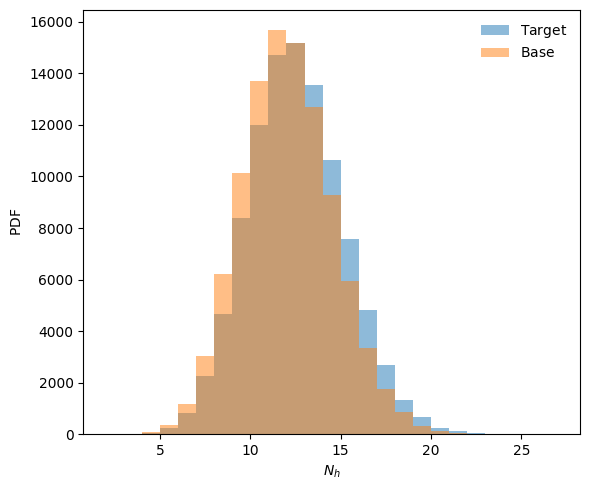

In [11]:
# Histrogram hadron multiplicity
fig, ax = plt.subplots(1,1,figsize=(6,5))

_, bins_target = np.histogram(mult_target)
_, bins_base = np.histogram(mult_base)

min_target, max_target = bins_target[0], bins_target[-1]
min_base, max_base = bins_base[0], bins_base[-1]

print(min_target, max_target)
#print(min_monash_prime, max_monash_prime)

min = np.min([min_target, min_base])
max = np.max([max_target, max_base])

bins = np.linspace(min, max, int((max - min)+1))

counts, _, _ = ax.hist(mult_target, bins, alpha = 0.5, density = False, label = r'$\mathrm{Target}$')# $(a = 0.68, b = 0.98)$')
ax.hist(mult_base, bins = bins, alpha = 0.5, density = False, label = r"$\mathrm{Base}$")
ax.set_xlabel(r'$N_h$')
ax.set_ylabel(r'$\mathrm{PDF}$')
ax.legend(frameon = False)
fig.tight_layout()

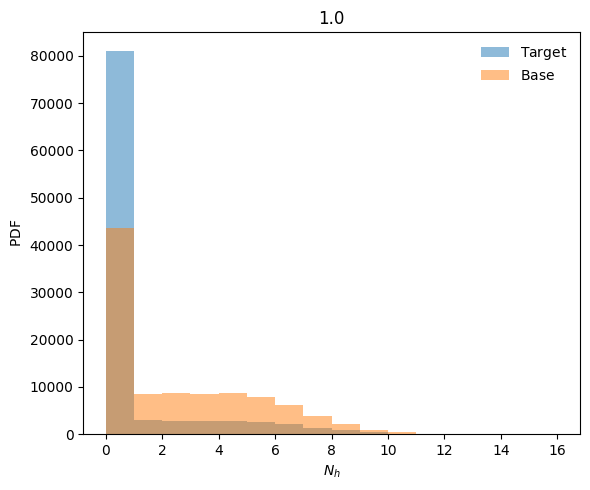

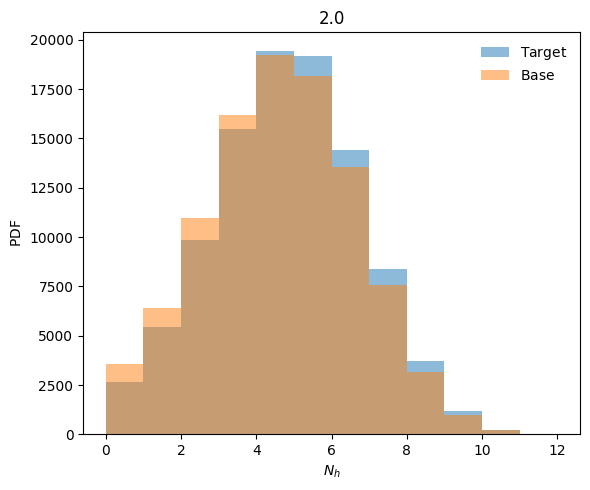

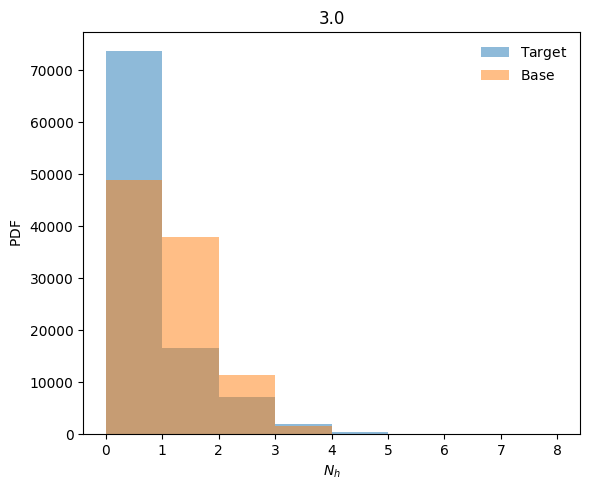

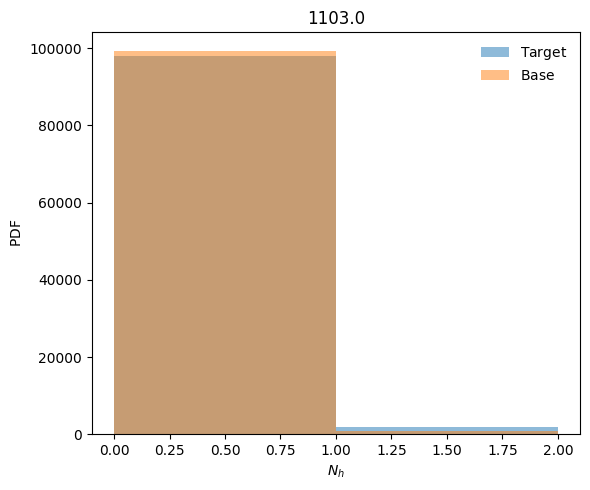

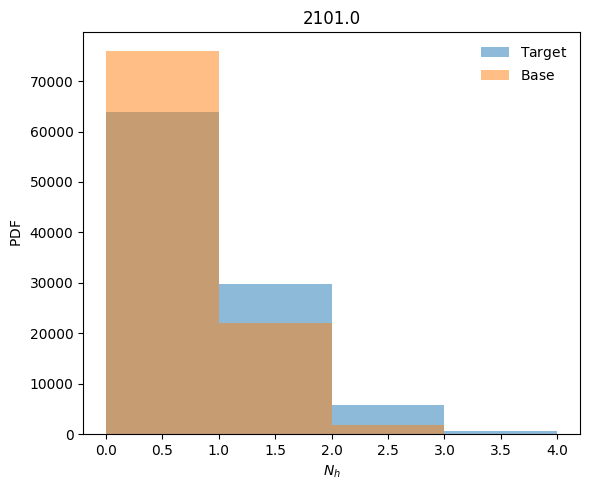

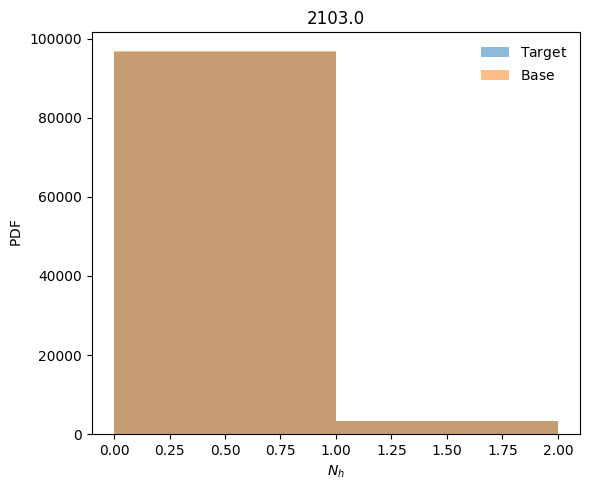

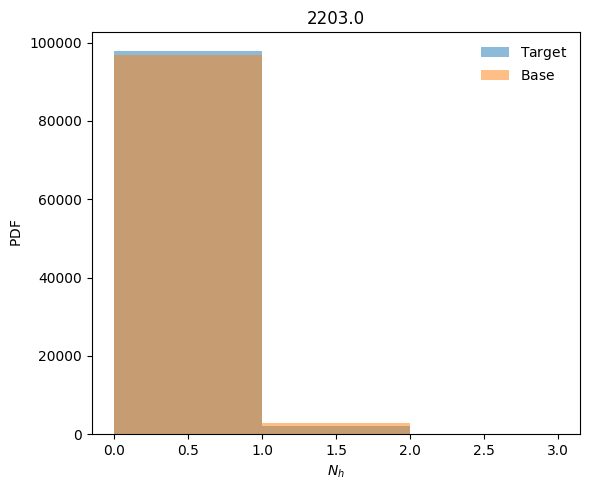

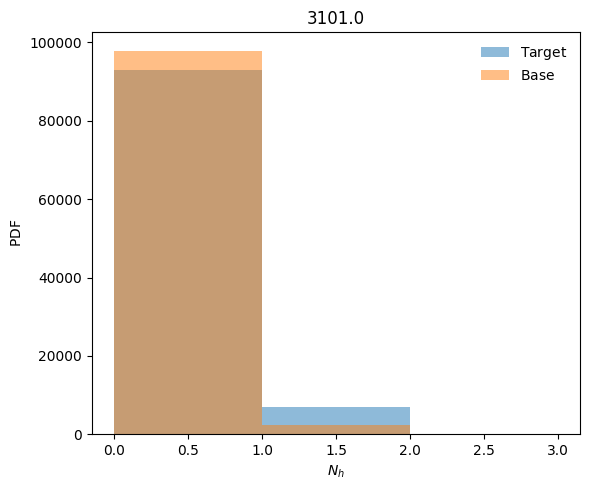

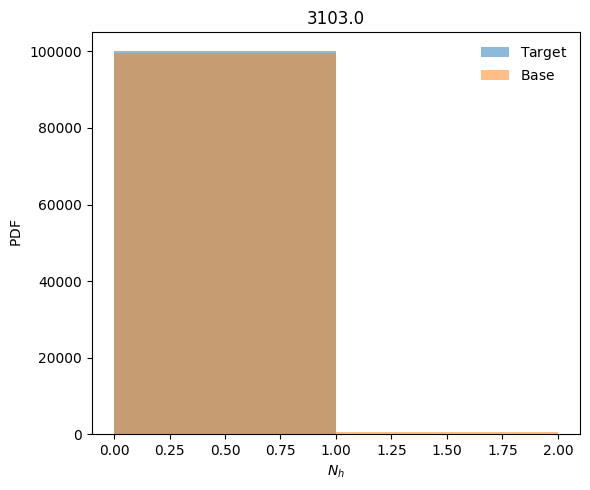

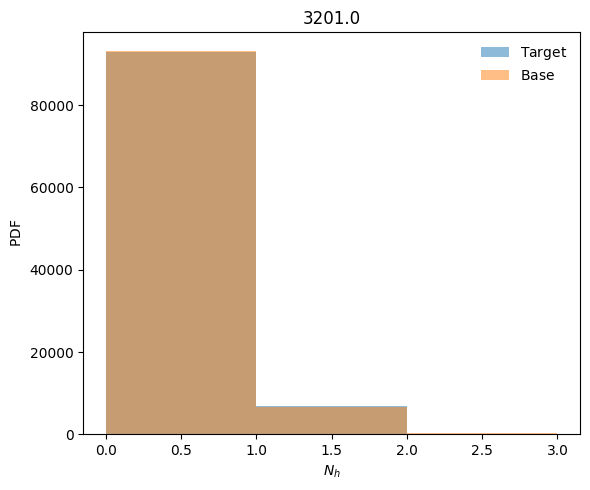

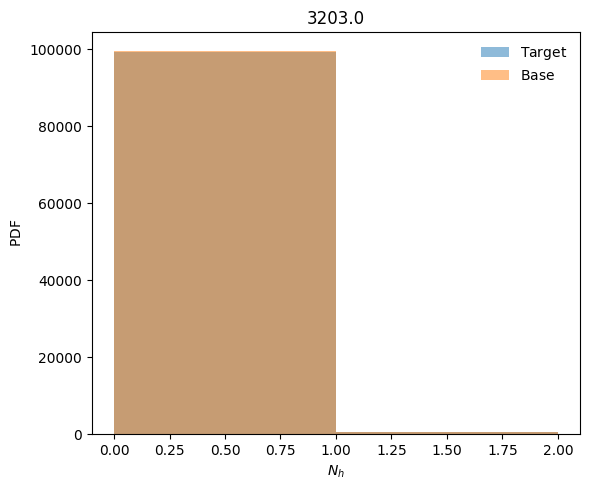

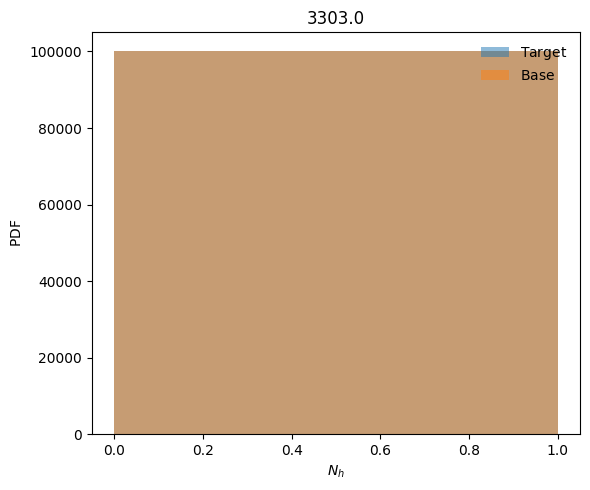

In [23]:
# with open("/pscratch/sd/l/ljpuslar/RSA/RSA/data/files/pythia_particles.json", "r") as f:
#     loaded_particles = json.load(f)

# ids_old = pgun_accept_reject_base[:,:,0][pgun_accept_reject_base[:,:,0] > 0.0]
Nevent = 100000

ids_new = np.abs(pgun_accept_reject_base[:,:,1][pgun_accept_reject_base[:,:,3] > 0.0])

# print(ids_old.shape)
particles, counts = np.unique(ids_new, return_counts=True)
len_par = len(particles)
# print(np.abs(pgun_hadrons_base[i,:,0]) > 0.0)
# print(np.abs(pgun_accept_reject_base[i,:,1]) == p)

for i,p in enumerate(particles):
    mult_base = np.array([len(pgun_hadrons_base[i,:][(np.abs(pgun_hadrons_base[i,:,0]) > 0.0)]) for i in range(Nevent)])
    mult_base_pid = []

    mult_target = np.array([len(pgun_hadrons_target[i,:][(np.abs(pgun_hadrons_target[i,:,0]) > 0.0)]) for i in range(Nevent)])
    mult_target_pid = []

    for ie in range(Nevent):
        mult_b = mult_base[ie]
        pgun_non_zero_b = np.array(np.abs(pgun_accept_reject_base[ie,:,1][pgun_accept_reject_base[i,:,3]>0]))
        mult_temp_b = len(pgun_non_zero_b[-mult_b:][pgun_non_zero_b[-mult_b:] == p])
        mult_base_pid.append(mult_temp_b)

        mult_t = mult_target[ie]
        pgun_non_zero_t = np.array(np.abs(pgun_accept_reject_target[ie,:,1][pgun_accept_reject_target[i,:,3]>0]))
        mult_temp_t = len(pgun_non_zero_t[-mult_t:][pgun_non_zero_t[-mult_t:] == p])
        mult_target_pid.append(mult_temp_t)

        

    # mult_base = np.array([len(pgun_hadrons_base[i,:][(np.abs(pgun_hadrons_base[i,:,0]) > 0.0) & (np.abs(pgun_accept_reject_base[i,:,1])) == p]) for i in range(Nevent)])
    # mult_target = np.array([len(pgun_hadrons_target[i,:][np.abs(pgun_hadrons_target[i,:,0]) > 0.0 & (np.abs(pgun_accept_reject_target[i,:,1])) == p]) for i in range(Nevent)])

    mult_base = np.array(mult_base_pid)
    mult_target = np.array(mult_target_pid)
    # print(mult_target)

    fig, ax = plt.subplots(1,1,figsize=(6,5))

    _, bins_target = np.histogram(mult_target)
    _, bins_base = np.histogram(mult_base)

    min_target, max_target = bins_target[0], bins_target[-1]
    min_base, max_base = bins_base[0], bins_base[-1]

    # print(min_target, max_target)
    #print(min_monash_prime, max_monash_prime)

    min = np.min([min_target, min_base])
    max = np.max([max_target, max_base])

    bins = np.linspace(min, max, int((max - min)+1))

    counts, _, _ = ax.hist(mult_target, bins, alpha = 0.5, density = False, label = r'$\mathrm{Target}$')# $(a = 0.68, b = 0.98)$')
    ax.hist(mult_base, bins = bins, alpha = 0.5, density = False, label = r"$\mathrm{Base}$")
    ax.set_xlabel(r'$N_h$')
    ax.set_ylabel(r'$\mathrm{PDF}$')
    ax.legend(frameon = False)
    ax.set_title(f'{p}')
    fig.tight_layout()


In [48]:
Nevent = 100000
# Collect multiplicity data
mult_base = np.array([len(pgun_hadrons_base[i,:][np.abs(pgun_hadrons_base[i,:,0]) > 0.0]) for i in range(Nevent)])
mult_target = np.array([len(pgun_hadrons_target[i,:][np.abs(pgun_hadrons_target[i,:,0]) > 0.0]) for i in range(Nevent)])

The reweighting module computes a weight array, given the base $B$ and perturbed $P$ parameterizations, according to 
$$
\boldsymbol{w} = \begin{pmatrix}
    w_1 \\
    w_2 \\
    \vdots \\
    w_N
  \end{pmatrix}, \text{ where } \\
  w_n = \prod_{i = 1}^{N_{h,n}} \left(\frac{f(z^{h_i}_\text{accept}; \{a, b\}_P)}{f(z^{h_i}_\text{accept}; \{a, b\}_{B})}\right)
  \prod_{j = 1}^{n_{h_i}} \left(\frac{\hat{f} - f(z^{j, h_i}_\text{reject}; \{a, b\}_P)}{\hat{f} - f(z^{j, h_i}_\text{reject}; \{a, b\}_{B}}\right)
$$
where $\hat{f}$ is the oversampling factor associated with the sampling of $z$ (here the over-sampling factor is 10). For each event, the accepcted and rejected $z$-values as well as the transverse mass $m_T^2 = p_x^2 + p_y^2 + m^2$ of each hadron is required to compute the event weight.

In [49]:
import torch
from torch import nn

class LundWeight(nn.Module):
    def __init__(self, params_base, params, over_sample_factor):
        super(LundWeight, self).__init__()
        """
        LundWeight class for computing event weights for the Lund fragmentation function

        Args:
            params_base (torch.Tensor): ------ Base parameters for the Lund fragmentation function
            params (torch.Tensor): ----------- Parameters for the Lund fragmentation function
            over_sample_factor (int): -------- Over-sampling factor for the rejected events
        """
        # Intialize the module parameters
        self.params_base = params_base
        # Initialize the params dictionary
        self.params = {}
        # Iterate of all keys in the dictionary and create a parameter for each key
        for key in params_base.keys():
            # print("params_base: ", params_base[key])
            if key in params and not torch.equal(params[key], params_base[key]):
                # print("params[key]: ", params[key])
                self.params[key] = torch.nn.Parameter(params[key], requires_grad = True)
                # print("params[key]: ", self.params[key].requires_grad)
            else:
                self.params[key] = params_base[key].clone().detach()

        # Initialize the over-sampling factor
        self.over_sample_factor = over_sample_factor

        # Constants for numerical stability checks
        self.AFROMZERO = 0.02
        self.EXPMAX = 50.
        self.AFROMC = 0.01

    def zMaxCalc(self, a, b, c):
        """
        Estimate the maximum value of z for the Lund fragmentation function
    
        Args:
            a (torch.Tensor): --------------- Parameter a
            b (torch.Tensor): --------------- Parameter b
            c (torch.Tensor): --------------- Parameter c
        
        Returns:
            zMax (torch.Tensor): Estimate for the maximum value of z given (a,b,c)
        """
        # Normalization for Lund fragmentation function so that f <= 1.
        # Special cases for a = 0 and a = c.
        aIsZero = (a < self.AFROMZERO)
        # if (aIsZero == 1).any():
        #     print('aIsZero: ', a)
        aIsC = (torch.abs(a - c) < self.AFROMC)
        
        # Initialize zMax tensor with the same shape as inputs
        zMax = torch.zeros_like(a, dtype = torch.float64)
        
        # Handle special case where a is zero
        zero_mask = aIsZero
        zMax[zero_mask] = torch.where(c[zero_mask] > b[zero_mask], b[zero_mask] / c[zero_mask], torch.ones_like(zMax[zero_mask], dtype = a.dtype))
        
        # Handle special case where a is essentially equal to c
        c_mask = aIsC & ~zero_mask
        zMax[c_mask] = b[c_mask] / (b[c_mask] + c[c_mask])
        
        # Handle the general case
        general_mask = ~(zero_mask | c_mask)
        if general_mask.any():
            # Compute zMax for the general case
            b_sub = b[general_mask]
            c_sub = c[general_mask]
            a_sub = a[general_mask]
            
            zMax_general = 0.5 * (b_sub + c_sub - torch.sqrt(torch.pow(b_sub - c_sub, 2) + 4 * a_sub * b_sub)) / (c_sub - a_sub)
            
            # Check for NaN values
            if torch.isnan(zMax_general).any():
                print('zMax_1', zMax_general)
                print('a', a[general_mask], 'b', b[general_mask], 'c', c[general_mask])
                exit()
            
            # Adjust zMax in numerically unstable regions 
            zMax_general = torch.where((zMax_general > 0.9999) & (b_sub > 100.), torch.min(zMax_general, 1. - a_sub / b_sub), zMax_general)
            zMax[general_mask] = zMax_general
        
        return zMax

    def likelihood(self, z, mT, a, b, c, z_mask = None, mT_mask = None, a_mask = None, b_mask = None, c_mask = None):
        """
        Compute the likelihood of the Lund fragmentation function

        Args:
            z (torch.Tensor): --------------- Input tensor
            mT (torch.Tensor): -------------- Transverse mass tensor (can be different shape from z)
            a (torch.Tensor): --------------- Parameter a
            b (torch.Tensor): --------------- Parameter b
            c (torch.Tensor): --------------- Parameter c (default: torch.tensor(1., requires_grad=True))
            z_mask (torch.Tensor, optional):  Boolean mask tensor for z (default: None)
            mT_mask (torch.Tensor, optional): Boolean mask tensor for mT (default: None)
            a_mask (torch.Tensor, optional): Boolean mask tensor for a (default: None)
            b_mask (torch.Tensor, optional): Boolean mask tensor for b (default: None)
            c_mask (torch.Tensor, optional): Boolean mask tensor for c (default: None)

        Returns:
            likelihood (torch.Tensor): Computed likelihood values (shape determined by broadcasting rules)
        """
        # Determine the shape after broadcasting
        broadcast_shape = torch.broadcast_shapes(z.shape, mT.shape, a.shape, b.shape, c.shape)

        # If no masks are provided, consider all elements
        if z_mask is None:
            z_mask = torch.ones(z.shape, dtype=torch.bool, device=z.device)
        if mT_mask is None:
            mT_mask = torch.ones(mT.shape, dtype=torch.bool, device=mT.device)
        if a_mask is None:
            a_mask = torch.ones(a.shape, dtype=torch.bool, device=a.device)
        if b_mask is None:
            b_mask = torch.ones(b.shape, dtype=torch.bool, device=b.device)
        if c_mask is None:
            c_mask = torch.ones(c.shape, dtype=torch.bool, device=c.device)

        # Broadcast z, mT, and their masks to the common shape
        z_broad = z.expand(broadcast_shape)
        mT_broad = mT.expand(broadcast_shape)
        a_broad = a.expand(broadcast_shape)
        b_broad = b.expand(broadcast_shape)
        c_broad = c.expand(broadcast_shape)
        z_mask_broad = z_mask.expand(broadcast_shape)
        mT_mask_broad = mT_mask.expand(broadcast_shape)
        a_mask_broad = a_mask.expand(broadcast_shape)
        b_mask_broad = b_mask.expand(broadcast_shape)
        c_mask_broad = c_mask.expand(broadcast_shape)
    
        # Combine masks
        combined_mask = z_mask_broad & mT_mask_broad & a_mask_broad & b_mask_broad & c_mask_broad

        # print('combined_maske: ', combined_mask[-1])
        
        # Create a tensor to store the results, initialized with zeros
        likelihood = torch.zeros(broadcast_shape, dtype=z.dtype, device=z.device)
    
        # Only perform calculations on unmasked elements
        z_unmasked = z_broad[combined_mask]
        mT_unmasked = mT_broad[combined_mask]
        a_unmasked = a_broad[combined_mask]
        b_unmasked = b_broad[combined_mask]
        c_unmasked = c_broad[combined_mask]
    
        # Check if we have any unmasked elements to process
        if z_unmasked.numel() > 0:
            # Adjust b-parameter
            b_exp = b_unmasked * mT_unmasked
            
            # Special case for a = 0.
            aIsZero = (a_unmasked < self.AFROMZERO)
            
            # Determine position of maximum.
            zMax = self.zMaxCalc(a_unmasked, b_exp, c_unmasked)
            
            # Be careful of -inf values in aCoeff, z is being rounded to exactly 1.
            aCoef = torch.log(1. - z_unmasked) - torch.log(1. - zMax)
            if torch.isneginf(aCoef).any():
                print('aCoef is returning -inf value, please check that all z < 1.')
                print('aCoeff', aCoef)
    
            bCoef = (1. / zMax) - (1. / z_unmasked)
            cCoef = torch.log(zMax) - torch.log(z_unmasked)
            fExp = b_exp * bCoef + c_unmasked * cCoef
            
            # Special cases for a = 0.
            not_zero_mask = ~aIsZero
            fExp[not_zero_mask] = fExp[not_zero_mask] + a_unmasked[not_zero_mask] * aCoef[not_zero_mask]
            
            # Feed through numerical stabilizer
            fVal = torch.exp(torch.clamp(fExp, min=-self.EXPMAX, max=self.EXPMAX))
            
            # Assign computed values back to the likelihood tensor
            likelihood[combined_mask] = fVal
        return likelihood

    def forward(self, z_mT2_pid, fPrel):
        """
        Forward pass of the weight module -- consists of computing the event weights for a given batch
        of training data.

        Args:
            z_mT2 (torch.Tensor): Tensor containing mT2 and z accept-reject data 
            fPrel (torch.Tensor): Tensor containing fPrel values

        Returns:
            weights (torch.Tensor): Computed event weights
        """
        batch_size = z_mT2_pid.shape[0]
        weights = torch.ones(batch_size)
        # Extract the (absolute value) pid values
        pid_old = torch.abs(z_mT2_pid[:, :, 0])
        pid_new = torch.abs(z_mT2_pid[:, :, 1])

        # Compute and create a, b, and c tensors for base and alternative parameters (This is a bottleneck, there isn't a good way to vectorize)
        a_old_base = torch.stack([torch.stack([self.params_base[f'a{int(pid_old[i,j].item())}'] for j in range(z_mT2_pid.shape[1])]) for i in range(batch_size)]).view(batch_size, z_mT2_pid.shape[1], 1)
        a_base = torch.stack([torch.stack([self.params_base[f'a{int(pid_new[i,j].item())}'] for j in range(z_mT2_pid.shape[1])]) for i in range(batch_size)]).view(batch_size, z_mT2_pid.shape[1], 1)
        b_base = torch.stack([torch.stack([self.params_base[f'b{int(pid_new[i,j].item())}'] for j in range(z_mT2_pid.shape[1])]) for i in range(batch_size)]).view(batch_size, z_mT2_pid.shape[1], 1)
        c_base = 1 + a_base - a_old_base
        # print(a_base)

        a_old_alt = torch.stack([torch.stack([self.params[f'a{int(pid_old[i,j].item())}'] for j in range(z_mT2_pid.shape[1])]) for i in range(batch_size)]).view(batch_size, z_mT2_pid.shape[1], 1)
        a_alt = torch.stack([torch.stack([self.params[f'a{int(pid_new[i,j].item())}'] for j in range(z_mT2_pid.shape[1])]) for i in range(batch_size)]).view(batch_size, z_mT2_pid.shape[1], 1)
        b_alt = torch.stack([torch.stack([self.params[f'b{int(pid_new[i,j].item())}'] for j in range(z_mT2_pid.shape[1])]) for i in range(batch_size)]).view(batch_size, z_mT2_pid.shape[1], 1)
        c_alt = 1 + a_alt - a_old_alt
        # print('a: ', a_alt[0])
        # print('c: ', c_alt[0])

        # Create masks for base and alternate parameters (masks should be the same)
        a_mask = a_base != 0.
        b_mask = b_base != 0.
        c_mask = a_base != 0.

        # Extract the mT2 values 
        mT2 = z_mT2_pid[:, :, 2]
        # Reshape into column tensor
        mT2 = mT2.view(mT2.shape[0], mT2.shape[1], 1)
        # Create a mask for zero values
        mT2_mask = mT2 != 0.

        # Extract the accepted z values
        z_accept = z_mT2_pid[:, :, 3]
        # Reshape into column tensor
        z_accept = z_accept.view(z_accept.shape[0], z_accept.shape[1], 1)
        # Remove any zero values
        z_accept_mask = z_accept != 0.

        # Extract the rejected z values
        z_reject = z_mT2_pid[:, :, 4:]
        # Reshape into column tensor
        z_reject = z_reject.view(z_reject.shape[0], z_reject.shape[1], z_reject.shape[2])
        # Remove any zero values along the event index
        z_reject_mask = z_reject != 0.

        # Extract the rejected fPrel values
        fPrel_reject = fPrel[:, :, 1:]
        fPrel_reject = fPrel_reject.view(fPrel_reject.shape[0], fPrel_reject.shape[1], fPrel_reject.shape[2])
        fPrel_reject_mask = fPrel_reject != 0.
        
        # Compute the accept and reject weights
        accept_weights = self.likelihood(z_accept, mT2, a_alt, b_alt, c_alt, z_mask = z_accept_mask, mT_mask = mT2_mask, a_mask = a_mask, b_mask = b_mask, c_mask = c_mask) \
                         / self.likelihood(z_accept, mT2, a_base, b_base, c_base, z_mask = z_accept_mask, mT_mask = mT2_mask, a_mask = a_mask, b_mask = b_mask, c_mask = c_mask)    
        reject_weights = ((self.over_sample_factor * (fPrel_reject * fPrel_reject_mask.masked_fill(z_accept_mask == 0, 1))) - self.likelihood(z_reject, mT2, a_alt, b_alt, c_alt, z_mask = z_reject_mask, mT_mask = mT2_mask, a_mask = a_mask, b_mask = b_mask, c_mask = c_mask)) \
                         / ((self.over_sample_factor * (fPrel_reject * fPrel_reject_mask.masked_fill(z_accept_mask == 0, 1))) - self.likelihood(z_reject, mT2, a_base, b_base, c_base, z_mask = z_reject_mask, mT_mask = mT2_mask, a_mask = a_mask, b_mask = b_mask, c_mask = c_mask))

        # Flatten the weights
        accept_weights = (accept_weights * z_accept_mask).masked_fill(z_accept_mask == 0, 1).prod(dim=2).prod(dim=1)
        reject_weights = (reject_weights * z_reject_mask).masked_fill(z_reject_mask == 0, 1).prod(dim=2).prod(dim=1)
            
        # The final event weight is the product of accepted and rejected weights
        weights = accept_weights * reject_weights
    
        return weights

In [50]:
# Set base (reference) parameterization
# aLundD = 0.61
# bLundD = 1.0
# aLundU = 0.78
# bLundU = 0.88
# aLundS = 0.48
# bLundS = 1.0
# aLundDiquark = 1.65
# bLundDiquark = 1.2

aExtraDQuark = 0
aExtraUQuark = 0
aExtraSQuark = 0
aExtraCquark = 0
aExtraBquark = 0
aExtraDiquark = 0.97

bNonstandardD = 0.88
bNonstandardU = 0.88
bNonstandardS = 0.88
bNonstandardC = 0.88
bNonstandardB = 0.88
bNonstandardH = 0.88

aLund = 0.68
bLund = 0.98

aLundD = aLund + aExtraDQuark
# bLundD = bNonstandardD
bLundD = bLund
aLundU = aLund + aExtraUQuark
# bLundU = bNonstandardU
bLundU = bLund
aLundS = aLund + aExtraSQuark
# bLundS = bNonstandardS
bLundS = bLund
aLundDiquark = aLund + aExtraDiquark
# bLundDiquark = bNonstandardH
bLundDiquark = bLund


params_base = {'a0': torch.tensor(0.0), 'b0': torch.tensor(0.0),
               'a1': torch.tensor(aLundD), 'b1': torch.tensor(bLundD), 'a2': torch.tensor(aLundU), 'b2': torch.tensor(bLundU),
               'a3': torch.tensor(aLundS), 'b3': torch.tensor(bLundS), 'a1103': torch.tensor(aLundDiquark), 'b1103': torch.tensor(bLundDiquark),
               'a2101': torch.tensor(aLundDiquark), 'b2101': torch.tensor(bLundDiquark), 'a2103': torch.tensor(aLundDiquark), 'b2103': torch.tensor(bLundDiquark),
               'a2203': torch.tensor(aLundDiquark), 'b2203': torch.tensor(bLundDiquark), 'a3101': torch.tensor(aLundDiquark), 'b3101': torch.tensor(bLundDiquark),
               'a3103': torch.tensor(aLundDiquark), 'b3103': torch.tensor(bLundDiquark), 'a3201': torch.tensor(aLundDiquark), 'b3201': torch.tensor(bLundDiquark),
               'a3203': torch.tensor(aLundDiquark), 'b3203': torch.tensor(bLundDiquark), 'a3303': torch.tensor(aLundDiquark), 'b3303': torch.tensor(bLundDiquark)}

# Set parameters to reweigh to (alternative parameterization)
# Technically should only include the parameters that are being reweighted
#aLundD_alt = 0.61
# bLundD_alt = 0.85 # Target v1
# aLundU_alt = 0.73 # Target v1
# bLundU_alt = 0.7  # Target v1

aLund_target = 0.68
bLund_target = 0.98

aLundU_alt = aLund_target + 0.04
aLundD_alt = aLund_target + 0.04
bLundU_alt = bLund_target - 0.1
bLundD_alt = bLund_target - 0.1

# aLundU_alt = 0.76
# aLundD_alt = 0.76
# bLundU_alt = 0.84
# bLundD_alt = 0.84

#bLundD_alt = 0.93 # Target v2
#aLundU_alt = 0.75 # Target v2
#bLundU_alt = 0.95  # Target v2
#aLundS_alt = 0.48
#bLundS_alt = 1.1
#aLundDiquark_alt = 1.65
#bLundDiquark_alt = 1.2
params_alt = {#'a0': torch.tensor(0.0), 'b0': torch.tensor(0.0),
              'a1': torch.tensor(aLundD_alt), 
              'a2': torch.tensor(aLundU_alt),
              'b1': torch.tensor(bLundD_alt),  
              'b2': torch.tensor(bLundU_alt)}
              #'b3': torch.tensor(bLundS_alt)}
              #'a3': torch.tensor(aLundS_alt), , 'a1103': torch.tensor(aLundDiquark_alt), 'b1103': torch.tensor(bLundDiquark_alt),
              #'a2101': torch.tensor(aLundDiquark_alt), 'b2101': torch.tensor(bLundDiquark_alt), 'a2103': torch.tensor(aLundDiquark_alt), 'b2103': torch.tensor(bLundDiquark_alt),
              #'a2203': torch.tensor(aLundDiquark_alt), 'b2203': torch.tensor(bLundDiquark_alt), 'a3101': torch.tensor(aLundDiquark_alt), 'b3101': torch.tensor(bLundDiquark_alt),
              #'a3103': torch.tensor(aLundDiquark_alt), 'b3103': torch.tensor(bLundDiquark_alt), 'a3201': torch.tensor(aLundDiquark_alt), 'b3201': torch.tensor(bLundDiquark_alt),
              #'a3203': torch.tensor(aLundDiquark_alt), 'b3203': torch.tensor(bLundDiquark_alt), 'a3303': torch.tensor(aLundDiquark_alt), 'b3303': torch.tensor(bLundDiquark_alt)}

# Set the over sample factor (for the pgun_qqbar datasets this is 10.)
over_sample_factor = 10.

print(params_alt)
# Initialize the reweighting module
reweighter = LundWeight(params_base, params_alt, over_sample_factor = over_sample_factor)

{'a1': tensor(0.7200), 'a2': tensor(0.7200), 'b1': tensor(0.8800), 'b2': tensor(0.8800)}


In [51]:
# print(reweighter.params)

# for k,v in reweighter.params.items():
#     print(v.requires_grad)

In [52]:
# Consider a 'batch' consisting of 10,000 events

nevents = 100000

# Target
pgun_accept_reject_base_torch = torch.from_numpy(pgun_accept_reject_base[0:nevents].copy())
pgun_fPrel_base_torch = torch.from_numpy(pgun_fPrel_base[0:nevents].copy())

# Check for values of 1 and correct
#epsilon = 1e-10
#pgun_accept_reject_target_torch[pgun_accept_reject_target_torch == 1] -= epsilon

pgun_mult_base_torch = torch.from_numpy(mult_base[0:nevents].copy())
pgun_mult_base_torch = torch.reshape(pgun_mult_base_torch, (nevents,1))

In [53]:
# Check the shapes
print(pgun_accept_reject_base_torch.shape)
print(pgun_fPrel_base_torch.shape)
print(pgun_mult_base_torch.shape)

torch.Size([100000, 250, 103])
torch.Size([100000, 250, 100])
torch.Size([100000, 1])


In [54]:
# Compute the weight array
weights = reweighter.forward(pgun_accept_reject_base_torch, pgun_fPrel_base_torch)
weights = weights.detach().numpy()
# print(type(weights))

# weights_path = f'/pscratch/sd/l/ljpuslar/RSA/RSA/data/weights/a{aLund}_b{bLund}_to_a{aLundU_alt}_b{bLundD_alt}_N{nevents}.npy'
weights_path = f'/pscratch/sd/l/ljpuslar/RSA/RSA/data/weights/a{aLund}_b{bLund}_to_aD{aLundD_alt}_bD{bLundU_alt}_N{nevents}.npy'
np.save(weights_path ,weights)

In [58]:
# aLund = 0.72
# bLund = 0.88
# aLundU_alt = 0.68
# bLundU_alt = 0.98
# aLund = 0.68
# bLund = 0.98
# aLundU_alt = 0.72
# bLundU_alt = 0.88

# weights_path = f'/pscratch/sd/l/ljpuslar/RSA/RSA/data/weights/a{aLund}_b{bLund}_to_a{aLundU_alt}_b{bLundD_alt}_N{nevents}.npy'
weights_path = f'/pscratch/sd/l/ljpuslar/RSA/RSA/data/weights/a{aLund}_b{bLund}_to_aD{aLundD_alt}_bD{bLundU_alt}_aU{aLundU_alt}_bU{bLundU_alt}_N{nevents}.npy'
np.save(weights_path ,weights)

# weights_path = f'/pscratch/sd/l/ljpuslar/RSA/RSA/data/weights/a{aLund}_b{bLund}_to_a{aLundU_alt}_b{bLundU_alt}_N{nevents}.npy'
# weights_path = f'/pscratch/sd/l/ljpuslar/RSA/RSA/data/weights/a{aLund}_aD0.15_bD0.68_b{bLund}_to_a{aLundU_alt}_b{bLundU_alt}_N{nevents}.npy'
weights_path = f'/pscratch/sd/l/ljpuslar/RSA/RSA/data/weights/a{aLund}_b{bLund}_to_aD{aLundD_alt}_bD{bLundU_alt}_aU{aLundU_alt}_bU{bLundU_alt}_N{nevents}.npy'

weights_loaded = np.load(weights_path)
weights_loaded = weights

In [59]:
# Compute the reweighting metrics (Target v1)
# print(weights_loaded.detach().numpy().shape)
# print(weights_loaded.detach().numpy())
one_minus_mu = 1. - np.sum(weights_loaded) / len(weights_loaded)
sigma_one_minus_mu = abs(1. - np.sqrt((np.sum(weights_loaded**2)/len(weights_loaded) - (np.sum(weights_loaded)/len(weights_loaded))**2)*len(weights_loaded)/(len(weights_loaded) - 1)))/np.sqrt(len(weights_loaded))
Neff = (np.sum(weights_loaded)**2 / np.sum(weights_loaded**2)) / len(weights_loaded)
print('1 - mu:', one_minus_mu, '+/-', sigma_one_minus_mu)
print('Neff:', Neff)

1 - mu: 0.0033368419248993586 +/- 0.0015564398310608314
Neff: 0.7939037574806526


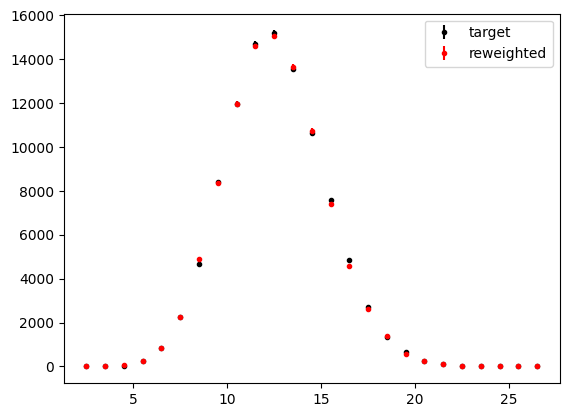

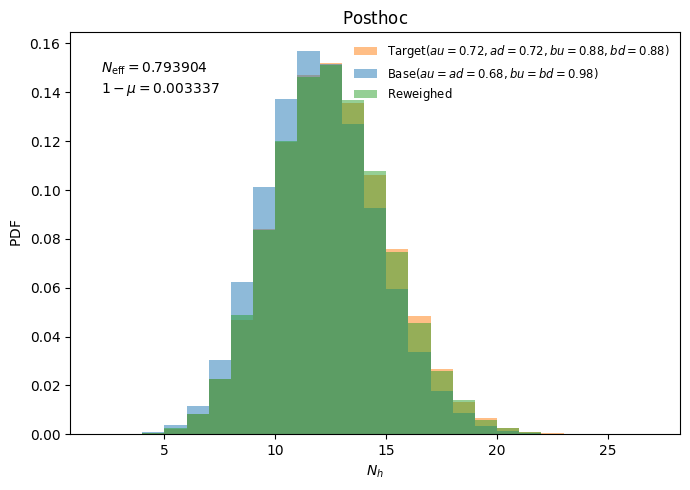

In [65]:
plt.figure()
# # print(type(mult_base[0:nevents]))
data_target = mult_target[0:nevents]
data_base = mult_base[0:nevents]

# # print(len(data_target))
# # weights_loaded
# = weights_loaded
#.detach().numpy()

# # Compute histogram and weighted errors
hist_vals_target, bin_edges_target = np.histogram(data_target, bins=bins)
bin_centers_target = 0.5 * (bin_edges_target[:-1] + bin_edges_target[1:])  # Compute bin centers

# # Compute errors (square root of sum of squared weights_loaded
# in each bin)
sum_all_weights_loaded = np.sum(weights_loaded)
errors_target = np.sqrt(hist_vals_target)
hist_weights_loaded, _ = np.histogram(data_base, bins=bins, weights=weights_loaded**2)
hist_wbase, _ = np.histogram(data_base, bins= bins, weights=weights_loaded)
errors_model = np.sqrt(hist_weights_loaded)

# hist_squared_weights_loaded
#, _ = np.histogram(data_target, bins=bins, weights_loaded
#=weights_loaded
#**2)
# # # print((hist_squared_weights_loaded
#)/sum_all_weights_loaded
#**2 )
# # # print(hist_weights_loaded
#**2/sum_all_weights_loaded
#**4 * np.sum(weights_loaded
#**2))
# errors_target = np.sqrt((hist_squared_weights_loaded
#)/sum_all_weights_loaded
#**2 + hist_weights_loaded
#**2/sum_all_weights_loaded
#**4 * np.sum(weights_loaded
#**2))plt.errorbar(bin_centers_target, hist_weights_loaded
#, yerr=errors_target, fmt=".", color="black", label="Error Bars")
plt.errorbar(bin_centers_target, hist_vals_target, yerr=errors_target, fmt=".", color="black", label="target")
plt.errorbar(bin_centers_target, hist_wbase, yerr=errors_model, fmt=".", color="red", label="reweighted")
# plt.errorbar(bin_centers_target, hist_weights_loaded
#, yerr=errors_model, fmt=".", color="blue", label="Error Bars")
plt.legend()


# Check the reweighed multiplicity historgram
fig, ax = plt.subplots(1,1,figsize=(7,5))

# ax.hist(mult_target[0:nevents], bins = bins, alpha = 0.5, label = r"$\mathrm{Target}$"+ rf"$(au = {aLundU_alt:.}, ad = {aLundD_alt}, bu = {bLundU_alt}, bd = {bLundD_alt})$", color = 'tab:orange', density = True)
ax.hist(mult_target[0:nevents], bins=bins, alpha=0.5, 
        label=rf"$\mathrm{{Target}}$" + 
              rf"$(au = {aLundU_alt:.2f}, ad = {aLundD_alt:.2f}, " + 
              rf"bu = {bLundU_alt:.2f}, bd = {bLundD_alt:.2f})$", 
        color='tab:orange', density=True)
ax.hist(mult_base[0:nevents], bins = bins, alpha = 0.5, label = r'$\mathrm{Base}$' + rf'$(au = ad = {aLund}, bu = bd = {bLund})$', color = 'tab:blue', density = True)
ax.hist(mult_base[0:nevents], bins = bins, weights = weights_loaded, alpha = 0.5, label = r"$\mathrm{Reweighed}$", color = 'tab:green', density = True)

# ax.errorbar(bin_centers_target, hist_vals_target, yerr=errors_target, fmt=".", color="black", label="Error Bars")


# Place the rewighting metrics on the upper left corner of the figure
ax.text(0.05, 0.9, rf'$N_{{\mathrm{{eff}}}} = {Neff:3f}$', fontsize = 10, transform = ax.transAxes)
ax.text(0.05, 0.85, rf'$1 - \mu = {one_minus_mu:3f}$', fontsize = 10, transform = ax.transAxes)

#ax.text(1.0, 0.10, rf'$N_{{\mathrm{{eff}}}} = {Neff:3f}$', fontsize = 10)
#ax.text(1.0, 0.10, rf'$N_{{\mathrm{{eff}}}} = {Neff:3f}$', fontsize = 10)
#ax.text(1.0, 0.095, rf'$1 - \mu = {one_minus_mu:3f}$', fontsize = 10)

ax.set_xlabel(r'$N_h$')
ax.set_ylabel(r'$\mathrm{PDF}$')
ax.legend(frameon = False, fontsize = 'small')
ax.set_title(r'$\mathrm{Posthoc}$')
fig.tight_layout()

# print(hist_vals)
# print(hist_vals_target)

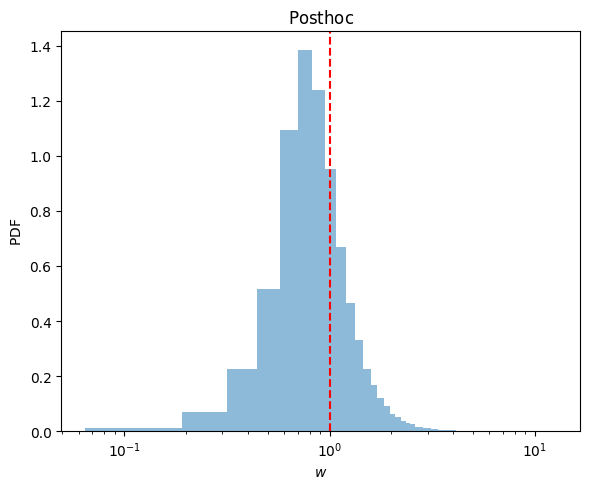

In [66]:
# Check the distribution of weights (Target v1)
fig, ax = plt.subplots(1,1,figsize=(6,5))
ax.hist(weights, 100, alpha = 0.5, density=True)
ax.set_xlabel(r'$w$')
ax.set_ylabel(r'$\mathrm{PDF}$')
ax.set_xscale('log')
ax.vlines(1., 0., 2., color = 'red', linestyle = '--', transform = ax.get_xaxis_transform())
ax.set_title(r'$\mathrm{Posthoc}$')
fig.tight_layout()

